In [44]:
import numpy as np
import pandas as pd
import cv2
from pathlib import Path

In [46]:
ROOT_DIR = Path('/Users/romitbarua/BreastCancerResearch/Ekyaalo-WSI-ROI-Detection')

In [54]:
# load the metadata
metadata = pd.read_csv(ROOT_DIR / 'data/metadata/metadata.csv')

# filter to just the train set
train_metadata = metadata[metadata['split'] == 'train']


# load the images (skip unreadable; resize to 400x400 for variable-sized patches)
TARGET_H, TARGET_W = 224, 224
img_list = []
for index, row in train_metadata.iterrows():
    image_path = row["filepath"]
    new_path = str(ROOT_DIR) + image_path
    image = cv2.imread(str(new_path))
    if image is None:
        print(f"Warning: could not read {new_path}")
        continue
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    if image.shape[0] != TARGET_H or image.shape[1] != TARGET_W:
        #raise ValueError(f"Image size mismatch: {image.shape[0]}x{image.shape[1]} != {TARGET_H}x{TARGET_W}")
        #print(f"Image size mismatch: {image.shape[0]}x{image.shape[1]} != {TARGET_H}x{TARGET_W}")
        image = cv2.resize(image, (TARGET_W, TARGET_H), interpolation=cv2.INTER_LINEAR)
    image = image.astype(np.float32) / 255.0
    img_list.append(image)

img_arr = np.array(img_list)
print(f"Loaded {len(img_list)} / {len(train_metadata)} images")




Loaded 518 / 518 images


In [55]:
img_arr.shape

(518, 224, 224, 3)

In [56]:
# get the per channel mean & std
channel_means = []
channel_stds = []
for i in range(3):
    channel_mean = np.mean(img_arr[:, :, :, i])
    channel_std = np.std(img_arr[:, :, :, i])
    print(f"Channel {i} mean: {channel_mean}, std: {channel_std}")
    channel_means.append(channel_mean)
    channel_stds.append(channel_std)




Channel 0 mean: 0.6629331111907959, std: 0.2630392014980316
Channel 1 mean: 0.6049708724021912, std: 0.28616929054260254
Channel 2 mean: 0.824263870716095, std: 0.14050175249576569


In [58]:
# get the grayscale mean & std
img_arry_gray = [cv2.cvtColor(img, cv2.COLOR_RGB2GRAY) for img in img_arr]
img_arry_gray = np.array(img_arry_gray)

print(img_arry_gray.shape)


channel_mean = np.mean(img_arry_gray[:, :, :])
channel_std = np.std(img_arry_gray[:, :, :])
print(f"Grayscale mean: {channel_mean}, std: {channel_std}")


(518, 224, 224)
Grayscale mean: 0.6473009586334229, std: 0.2582257390022278


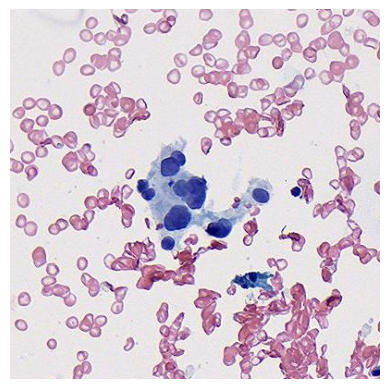

In [32]:
import matplotlib.pyplot as plt

image = cv2.imread(test_path)
if image is not None:
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    plt.imshow(image_rgb)
    plt.axis('off')
    plt.show()
else:
    print(f"Failed to load image at {test_path}")